# Customer Segmentation on the Online Retail Dataset

This notebook groups customers into simple segments based on what they buy and how often they buy it.

Part 1 uses **K-Means**.
Part 2 uses **DBSCAN**.


## Part 1: Build features and run K-Means

### Load and prepare the data
We load the retail data, turn the date column into a real date, and calculate the total value of each purchase line.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Retail dataset from UCI
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

df = pd.read_excel(data_url)

# Make the date column usable for time-based features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Total value for each transaction line
df['Total_Bill'] = df['Quantity'] * df['UnitPrice']

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Bill
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Build customer-level features
Now we compress the data so each customer has one row.

We keep a few simple signals:
- total money spent
- first and last purchase date
- how long the customer has been active
- most common country
- most common item code

In [2]:
customer_df = df.groupby('CustomerID').agg(
    Total_Bill_Size=('Total_Bill', 'sum'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max'),
    Most_Common_Location=('Country', lambda x: x.mode()[0]),
    Top_Item=('StockCode', lambda x: x.value_counts().idxmax())
)

# How long the customer stayed active
customer_df['Purchase_Interval_Days'] = (customer_df['Last_Purchase'] - customer_df['First_Purchase']).dt.days

customer_df.reset_index(inplace=True)

customer_df.head()


,CustomerID,Total_Bill_Size,First_Purchase,Last_Purchase,Most_Common_Location,Top_Item,Purchase_Interval_Days
0,12346.0,0.00,2011-01-18 10:01:00,2011-01-18 10:17:00,United Kingdom,23166,0
1,12347.0,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,22375,365
2,12348.0,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,POST,282
3,12349.0,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,23112,0
4,12350.0,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,21908,0


### Run K-Means
K-Means works better when values are on the same scale, so we standardize total spend first. Then we split customers into 3 groups by spend.

In [3]:
# Put spend on a standard scale
scaler = StandardScaler()
customer_df['Total_Bill_Size_Scaled'] = scaler.fit_transform(customer_df[['Total_Bill_Size']])

# Group customers by spend
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(customer_df[['Total_Bill_Size_Scaled']])

customer_df.head()


,CustomerID,Total_Bill_Size,First_Purchase,Last_Purchase,Most_Common_Location,Top_Item,Purchase_Interval_Days,Total_Bill_Size_Scaled,Cluster
0,12346.0,0.00,2011-01-18 10:01:00,2011-01-18 10:17:00,United Kingdom,23166,0,-0.231001,0
1,12347.0,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,22375,365,0.293432,0
2,12348.0,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,POST,282,-0.012316,0
3,12349.0,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,23112,0,-0.017146,0
4,12350.0,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,21908,0,-0.190312,0


### Check the number of clusters
This chart helps us see whether 3 clusters makes sense, or whether another value of `k` would be better.

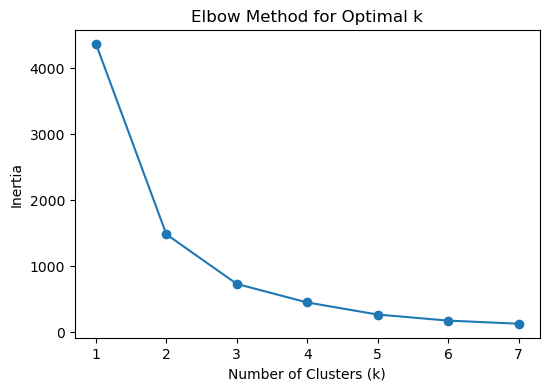

In [4]:
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(customer_df[['Total_Bill_Size_Scaled']])
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


### Cluster summaries
For each group, we print how many customers it has and what those customers usually look like.

In [5]:
def summarize_cluster_info(clustered_df, model):
    for i in range(model.n_clusters):
        cluster_data = clustered_df[clustered_df['Cluster'] == i]
        print(f"\nCluster {i} Summary:")

        customer_count = len(cluster_data)
        print(f"Number of Customers in the cluster: {customer_count}")

        avg_spend = cluster_data['Total_Bill_Size'].mean()
        print(f"Average Spend: ${avg_spend:.2f}")

        avg_interval = cluster_data['Purchase_Interval_Days'].mean()
        print(f"Average Purchase Interval: {avg_interval:.2f} days")

        top_locations = cluster_data['Most_Common_Location'].value_counts().head(3)
        print("Top 3 Locations:")
        for location, count in top_locations.items():
            print(f"  {location}: {count} customers")

        top_items = cluster_data['Top_Item'].value_counts().head(3)
        print("Top 3 Item Codes:")
        for item, count in top_items.items():
            print(f"  {item}: {count} times purchased")

summarize_cluster_info(customer_df, kmeans)



Cluster 0 Summary:
Number of Customers in the cluster: 4346
Average Spend: $1434.20
Average Purchase Interval: 132.11 days
Top 3 Locations:
  United Kingdom: 3929 customers
  Germany: 95 customers
  France: 87 customers
Top 3 Item Codes:
  POST: 127 times purchased
  85123A: 92 times purchased
  22423: 90 times purchased

Cluster 1 Summary:
Number of Customers in the cluster: 3
Average Spend: $241136.56
Average Purchase Interval: 359.33 days
Top 3 Locations:
  United Kingdom: 2 customers
  Netherlands: 1 customers
Top 3 Item Codes:
  22629: 1 times purchased
  22470: 1 times purchased
  22189: 1 times purchased

Cluster 2 Summary:
Number of Customers in the cluster: 23
Average Spend: $58418.75
Average Purchase Interval: 344.74 days
Top 3 Locations:
  United Kingdom: 19 customers
  EIRE: 2 customers
  Australia: 1 customers
Top 3 Item Codes:
  22197: 4 times purchased
  C2: 2 times purchased
  22630: 1 times purchased


**What K-Means is doing here:** when we cluster only by spending, most customers end up in one big group, while a few very large spenders get pulled into tiny groups. That happens because K-Means is sensitive to extreme values. It is useful, but it does not always give the most natural customer segments.

## Part 2: Run DBSCAN

DBSCAN looks for dense pockets of customers and leaves unusual points alone as **noise** (`-1`). Here we use two features: spend and purchase interval.

### Load and build the features
(This section repeats the setup so it can run on its own.)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(data_url)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Total_Bill'] = df['Quantity'] * df['UnitPrice']

customer_df = df.groupby('CustomerID').agg(
    Total_Bill_Size=('Total_Bill', 'sum'),
    Purchase_Interval_Days=('InvoiceDate', lambda x: (x.max() - x.min()).days)
).reset_index()

# Scale both features so one does not overpower the other
scaler = StandardScaler()
features = scaler.fit_transform(customer_df[['Total_Bill_Size', 'Purchase_Interval_Days']])

customer_df.head()


### Run DBSCAN
DBSCAN has two main settings:
- **eps**: how close points need to be to count as neighbors
- **min_samples**: how many nearby points are needed to form a cluster

Points that do not fit anywhere get label `-1`, which means noise.

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(features)

customer_df['Cluster'] = clusters

print("Cluster counts:")
print(customer_df['Cluster'].value_counts())

noise = customer_df[customer_df['Cluster'] == -1]
print(f"\nNoise points count: {len(noise)}")


### Silhouette score
This tells us how cleanly the clusters separate. Higher is better. We skip noise points here.

In [ ]:
mask = clusters != -1
if mask.sum() > 1 and len(set(clusters[mask])) > 1:
    sil_score = silhouette_score(features[mask], clusters[mask])
    print(f"Silhouette Coefficient (excluding noise): {sil_score:.2f}")
else:
    print("Not enough distinct clusters (excluding noise) to compute a silhouette score.")


### Visualize the clusters

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(features[:, 0], features[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title('DBSCAN Clustering')
plt.xlabel('Scaled Total Bill Size')
plt.ylabel('Scaled Purchase Interval Days')
plt.colorbar(label='Cluster Label')
plt.show()


### Cluster summaries

In [ ]:
def summarize_clusters(df):
    grouped = df.groupby('Cluster')
    for key, group in grouped:
        if key == -1:
            continue  # Handle noise points separately
        print(f"\nCluster {key} Summary:")
        print(f"Number of Customers: {len(group)}")
        avg_bill = group['Total_Bill_Size'].mean()
        avg_interval = group['Purchase_Interval_Days'].mean()
        print(f"Average Total Bill: {avg_bill:.2f}")
        print(f"Average Purchase Interval: {avg_interval:.2f}")

summarize_clusters(customer_df)

print(f"\nNoise points: {len(noise)} customers that didn't fit densely into any cluster")
print(f"Average Total Bill (noise): {noise['Total_Bill_Size'].mean():.2f}")
print(f"Average Purchase Interval (noise): {noise['Purchase_Interval_Days'].mean():.2f}")


## K-Means vs. DBSCAN

- **K-Means** always puts every customer into a cluster, even when some customers are just outliers.
- **DBSCAN** can leave unusual customers out as noise instead of forcing them into a group.
- The silhouette score here is fairly strong, which means the DBSCAN clusters are reasonably well separated.
- In simple terms, DBSCAN is often easier to trust for skewed retail spending data because it handles unusual customers better.